## Load Libraries

In [ ]:
# Ensure local package path is first
import sys
from pathlib import Path

# Now import libraries
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
import importlib

# Reload to pick up code changes
import galform_analysis.analysis.correlation.correlation as corr_module
import galform_analysis.analysis.correlation.plot_correlation as plot_corr_module

# Import updated functions after reload
from galform_analysis.analysis.correlation.plot_correlation import (
    plot_single_correlation,
    plot_correlation_multi_redshift,
    plot_avg_correlation_over_redshifts,
)
from galform_analysis.analysis import correlation_given_redshift_and_subvolume

# Ensure we see latest code before symbol imports
importlib.reload(corr_module)
importlib.reload(plot_corr_module)

project_root = Path.cwd().parent
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

base_dir = get_base_dir()

# Plotting defaults (match compare_mass_functions style)
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## 2PCF for a given snapshot and subvolume

[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?


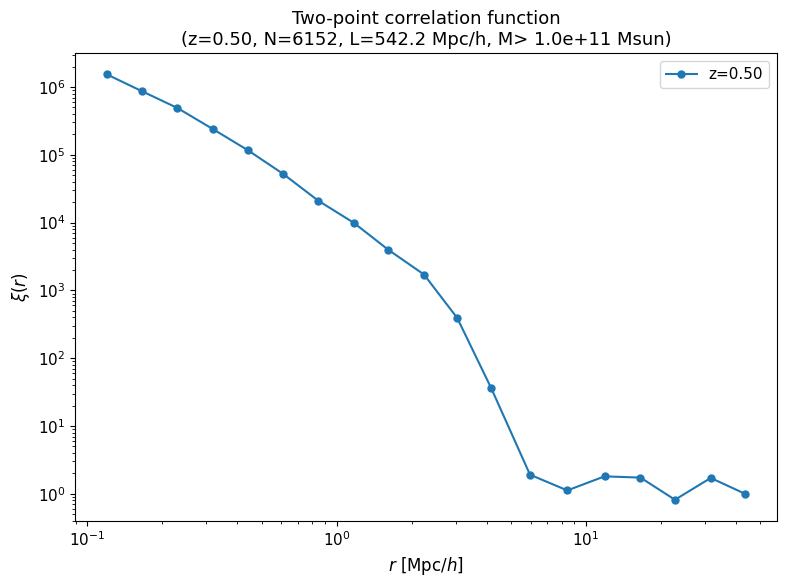

  Redshift: 0.4959
  N_gal: 6152
  Boxsize: 542.2 Mpc/h
  V_ivol: 1.556e+05 Mpc³

     r [Mpc/h]          ξ(r)
  --------------------------
          0.12  1535985.449338
          0.23  492273.397276
          0.44  116245.792142
          0.84  21107.919079
          1.61   3965.779275
          3.05    391.960858
          5.97      1.912794
         11.88      1.807498
         22.77      0.816683
         43.52      0.999268


In [2]:
example_snapshot = 'iz207'
example_ivol = 100
snap_path = str(base_dir / example_snapshot)

# Define bin edges
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)

# Optional: apply a minimum halo mass cut (Msun)
mhalo_min = 1e11  # e.g., 1e11 to keep halos >= 1e11 Msun

# Compute and plot using the module
result = plot_single_correlation(
    snap_path,
    example_ivol,
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
    figsize=(8, 6),
    show_plot=True
)

if result is not None:
    print(f"  Redshift: {result['z']:.4f}")
    print(f"  N_gal: {result['ngal']}")
    print(f"  Boxsize: {result['boxsize']:.1f} Mpc/h")
    print(f"  V_ivol: {result['V_ivol']:.3e} Mpc³")
    print(f"\n  {'r [Mpc/h]':>12}  {'ξ(r)':>12}")
    print("  " + "-" * 26)
    r = result['r']
    xi = result['xi']
    for i in range(0, len(r), 2):
        if np.isfinite(xi[i]):
            print(f"  {r[i]:12.2f}  {xi[i]:12.6f}")

## 2PCF for one subvolume across multiple redshifts (overlay)

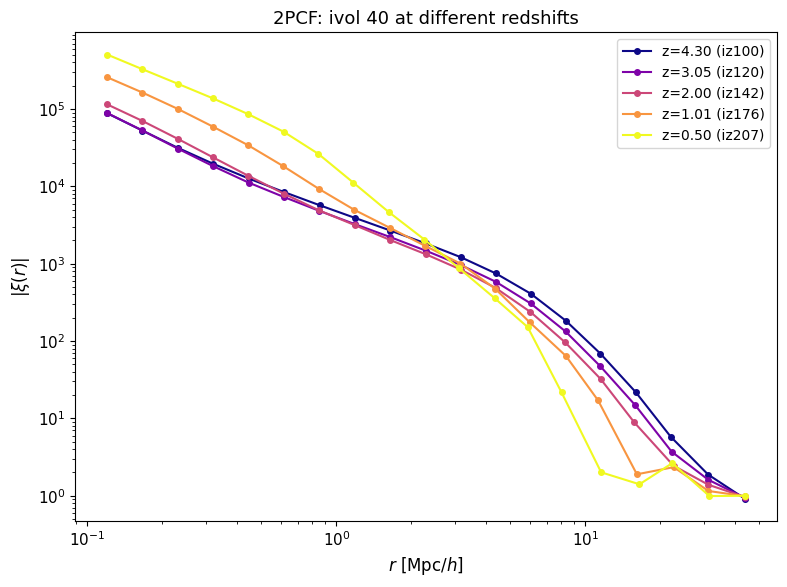

In [6]:
example_ivol = 40
iz_nums = [100, 120, 142, 176, 207]#, 271]

results = plot_correlation_multi_redshift(
    iz_nums=iz_nums,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    show_plot=True,
    colormap='plasma'
)

## Average 2PCF over multiple redshifts for one subvolume

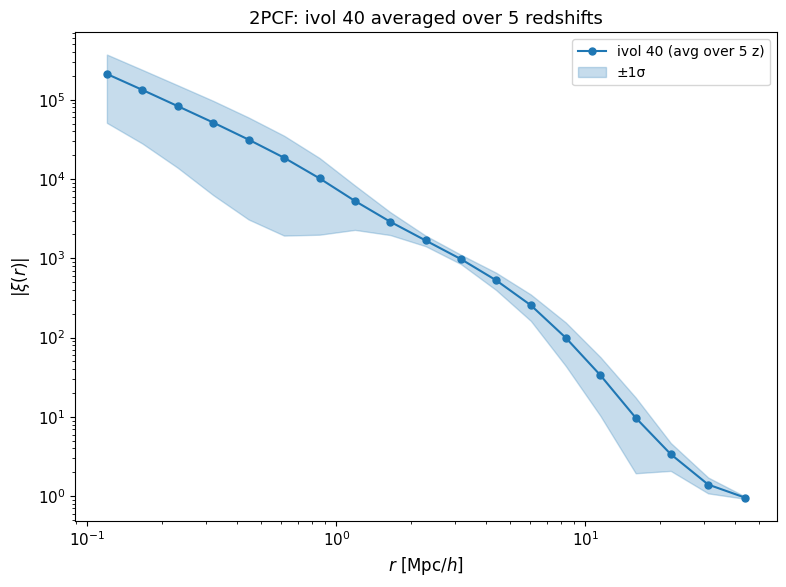

Averaged over 5 redshifts for ivol 40
First 5 (r, xi, xi_std):
     0.120  2.115932e+05  1.604251e+05
     0.166  1.333586e+05  1.052641e+05
     0.230  8.327134e+04  6.936000e+04
     0.320  5.160100e+04  4.532956e+04
     0.444  3.143597e+04  2.834490e+04


In [ ]:
example_ivol = 40
iz_nums = [100, 120, 142, 176, 207]  

avg_result = plot_avg_correlation_over_redshifts(
    iz_nums=iz_nums,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    show_plot=True,
)

if avg_result is not None:
    r = avg_result['r']
    xi = avg_result['xi']
    xi_std = avg_result.get('xi_std', None)
    n_used = avg_result.get('n_used', 0)

    print(f"Averaged over {n_used} redshifts for ivol {example_ivol}")
    if xi_std is not None:
        print("First 5 (r, xi, xi_std):")
        for i in range(min(5, len(r))):
            print(f"  {r[i]:8.3f}  {xi[i]:12.6e}  {xi_std[i]:12.6e}")
